# AICE Associate 시험 당일 최종 회독

**목적:** 새로운 내용을 배우는 문제가 아니라, 시험 직전에 전체 흐름을 한 번 실행해 보는 모의 세트입니다.

### 진행 규칙
- 가능하면 검색 없이 먼저 풉니다.
- 한 문제에 오래 붙잡히지 말고 `# 복습 필요`라고 적고 넘어갑니다.
- 문제에 없는 불필요한 전처리는 하지 않습니다.
- 아래 세 파일은 이 노트북과 같은 폴더에 둡니다.
  - `aice_final_binary.csv`
  - `aice_final_regression.csv`
  - `aice_final_multiclass.csv`

> 정답 코드는 포함되어 있지 않습니다.


## PART 1. 공통 데이터 처리 / EDA

### 1
`aice_final_binary.csv`를 불러와 `data`에 저장하고 데이터의 크기, 컬럼 정보, 앞부분 5행을 확인하세요.

In [59]:
# 여기에 답안코드를 작성하고 실행하세요
import pandas as pd

data = pd.read_csv('aice_final_binary.csv')
print(data.shape)
print(data.info())
data.head()

(724, 10)
<class 'pandas.DataFrame'>
RangeIndex: 724 entries, 0 to 723
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   customer_id    724 non-null    str    
 1   age            724 non-null    int64  
 2   monthly_spend  706 non-null    float64
 3   visits_30d     724 non-null    int64  
 4   support_calls  724 non-null    int64  
 5   membership     710 non-null    str    
 6   region         724 non-null    str    
 7   signup_date    716 non-null    str    
 8   device         724 non-null    str    
 9   churn          724 non-null    int64  
dtypes: float64(1), int64(4), str(5)
memory usage: 56.7 KB
None


,customer_id,age,monthly_spend,visits_30d,support_calls,membership,region,signup_date,device,churn
0,C10000,59,NaN,11,5,Gold,Busan,2023-12-31,Android,1
1,C10001,45,56776.0,10,3,Gold,Daejeon,2024-04-10,Android,0
2,C10002,48,119889.0,5,1,Silver,Seoul,2026-02-20,iOS,0
3,C10003,25,80395.0,0,2,Gold,Busan,2024-08-12,Android,1
4,C10004,43,82117.0,6,1,Silver,Daejeon,2024-06-28,Android,0


### 2
각 컬럼의 결측치 개수를 확인하세요.  
`monthly_spend`는 **중앙값**, `membership`는 **최빈값**으로 처리하고, `signup_date`의 결측 행은 제거하세요.

In [60]:
# 여기에 답안코드를 작성하고 실행하세요
data['monthly_spend'] = data['monthly_spend'].fillna(data['monthly_spend'].median())
data['membership'] = data['membership'].fillna(data['membership'].mode()[0])

In [61]:
data = data.dropna(subset=['signup_date'])

### 3
중복 행을 확인한 뒤 모두 제거하고 인덱스를 0부터 다시 정렬하세요.

In [62]:
# 여기에 답안코드를 작성하고 실행하세요
data = data.drop_duplicates().reset_index(drop=True)

### 4
`signup_date`를 날짜형으로 변환하고 `signup_year`, `signup_month` 파생변수를 생성하세요.  
변환이 끝나면 원래 `signup_date` 컬럼은 제거하세요.

In [63]:
# 여기에 답안코드를 작성하고 실행하세요
data['signup_date'] = pd.to_datetime(data['signup_date'])

data['signup_year'] = data['signup_date'].dt.year
data['signup_month'] = data['signup_date'].dt.month

data = data.drop(columns='signup_date')

### 5
`churn`의 클래스별 개수를 확인하고 그래프로 시각화하세요.  
또한 `membership`별 `churn` 평균을 구하세요.

churn
0    659
1     53
Name: count, dtype: int64


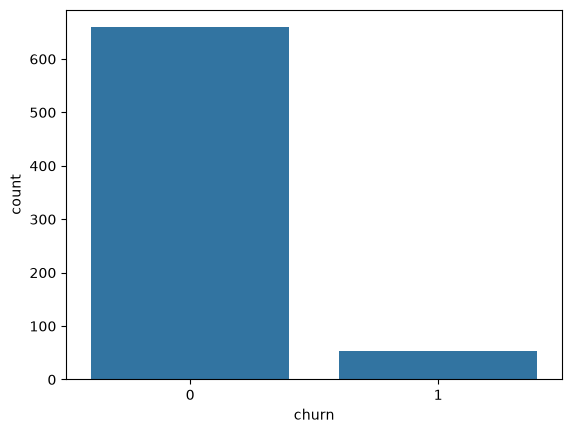

In [64]:
# 여기에 답안코드를 작성하고 실행하세요
import matplotlib.pyplot as plt
import seaborn as sns

print(data['churn'].value_counts())

sns.countplot(data=data, x='churn')
plt.show()


In [65]:
data.groupby('membership')['churn'].mean()

membership
Basic     0.094395
Gold      0.061538
Silver    0.053498
Name: churn, dtype: float64

### 6
수치형 컬럼의 상관계수를 구하고 heatmap으로 시각화하세요.

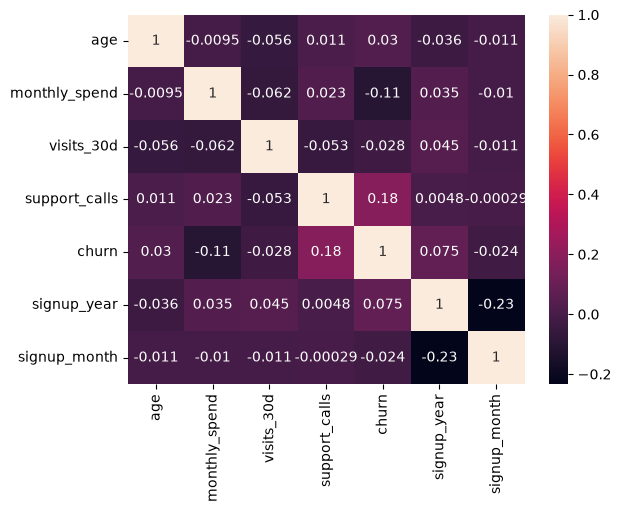

In [66]:
# 여기에 답안코드를 작성하고 실행하세요
corr = data.corr(numeric_only=True)
sns.heatmap(corr, annot=True)
plt.show()

## PART 2. 이진 분류

### 7
`customer_id`는 분석에서 제외하세요.  
범주형 변수를 모델 학습이 가능한 형태로 변환한 뒤 입력변수 `X`, 타깃 `y`로 분리하세요.

In [67]:
# 여기에 답안코드를 작성하고 실행하세요
data = data.drop('customer_id', axis=1)

In [68]:
data['membership'] = data['membership'].map({
  'Basic':0,
  'Silver':1,
  'Gold':2
})

data = pd.get_dummies(data, columns=['region','device', 'signup_year'], dtype=int)


In [69]:
X = data.drop(columns=['churn'])
y = data['churn']

### 8
학습용과 테스트용 데이터를 8:2로 분리하세요.  
`random_state=42`를 사용하고 타깃 비율이 유지되도록 설정하세요.

In [70]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.model_selection import train_test_split

X_train, X_valid, y_train, y_valid = train_test_split(
  X,
  y,
  test_size=0.2,
  random_state=42,
  stratify=y
)

### 9
연속형 입력값의 크기를 표준화한 뒤 Logistic Regression 모델을 학습하세요.  
테스트 데이터에 대한 예측값을 생성하세요.

In [71]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

lr = LogisticRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_valid_scaled)


### 10
Accuracy, Precision, Recall, F1-score와 Confusion Matrix를 출력하세요.

In [72]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

print(accuracy_score(y_valid, lr_pred))
print(precision_score(y_valid, lr_pred))
print(recall_score(y_valid, lr_pred))
print(f1_score(y_valid, lr_pred))
print(confusion_matrix(y_valid, lr_pred))

0.9230769230769231
0.0
0.0
0.0
[[132   0]
 [ 11   0]]


c:\Users\kom73\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


### 11
테스트 데이터에서 클래스 1일 확률을 구하고 ROC-AUC를 계산하세요.

In [73]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.metrics import roc_auc_score

lr_proba = lr.predict_proba(X_valid_scaled)[:,1]

roc_auc_score(y_valid, lr_proba)

0.790633608815427

### 12
클래스 1의 판정 임계값을 **0.30**으로 변경하여 새로운 예측값을 생성하세요.  
기본 임계값 결과와 비교해 Precision과 Recall이 어떻게 변했는지 확인하세요.

In [74]:
# 여기에 답안코드를 작성하고 실행하세요
lr_pred_03 = (lr_proba>=0.3).astype(int)

print(precision_score(y_valid, lr_pred_03))
print(recall_score(y_valid, lr_pred_03))

# 기본 임계값과 비교해 둘 다 올랐다.

0.5
0.18181818181818182


## PART 3. 회귀

### 13
`aice_final_regression.csv`를 `reg_data`에 불러오세요.  
결측치를 확인하고 `weight_kg`는 중앙값, `package_type`은 최빈값으로 처리하세요.

In [75]:
# 여기에 답안코드를 작성하고 실행하세요
reg_data = pd.read_csv('aice_final_regression.csv')

reg_data.isnull().sum()

order_id              0
order_date            0
distance_km           0
weight_kg            11
package_type          9
traffic               0
weather               0
delivery_time_min     0
dtype: int64

In [76]:
reg_data['weight_kg'] = reg_data['weight_kg'].fillna(reg_data['weight_kg'].median())
reg_data['package_type'] = reg_data['package_type'].fillna(reg_data['package_type'].mode()[0])

### 14
`package_type` 값 중 문자열에 `fragile`이 포함된 값은 모두 `fragile`로 변경하세요.  
그 외 `small`, `medium`, `large` 값은 그대로 유지하세요.

In [80]:
# 여기에 답안코드를 작성하고 실행하세요
reg_data.loc[reg_data['package_type'].isin(['small|fragile','medium|fragile','large|fragile']), 'package_type'] = 'fragile'
reg_data['package_type'].value_counts()

package_type
fragile    192
medium     165
small      119
large       84
Name: count, dtype: int64

### 15
`order_date`에서 월(`order_month`)을 추출한 뒤 원본 날짜 컬럼과 `order_id`를 제거하세요.  
범주형 컬럼을 인코딩하세요.

In [81]:
# 여기에 답안코드를 작성하고 실행하세요
reg_data['order_date'] = pd.to_datetime(reg_data['order_date'])

reg_data['order_month'] = reg_data['order_date'].dt.month

reg_data = reg_data.drop('order_date', axis=1)

In [87]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

reg_data['weather'] = le.fit_transform(reg_data['weather'])


In [88]:
reg_data = pd.get_dummies(reg_data, columns=['package_type', 'traffic'], dtype=int)

In [91]:
reg_data = reg_data.drop('order_id', axis=1)

### 16
타깃을 `delivery_time_min`으로 지정하여 학습/테스트 데이터를 8:2로 분리하고 Linear Regression 모델을 학습하세요.

In [94]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.linear_model import LinearRegression

X = reg_data.drop('delivery_time_min', axis=1)
y = reg_data['delivery_time_min']

X_train, X_valid, y_train, y_valid = train_test_split(
  X,
  y,
  test_size=0.2
)

logi_model = LinearRegression()

logi_model.fit(X_train, y_train)

logi_pred = logi_model.predict(X_valid)


### 17
테스트 데이터의 MAE, MSE, RMSE, R²를 계산하세요.

In [95]:
# 여기에 답안코드를 작성하고 실행하세요
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_valid, logi_pred)
mse = mean_squared_error(y_valid, logi_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_valid, logi_pred)

print(mae)
print(mse)
print(rmse)
print(r2)

7.634899293455237
102.64030004835998
10.131154921743127
0.9202672344436074


## PART 4. 다중분류 + 딥러닝

### 18
`aice_final_multiclass.csv`를 `multi_data`로 불러오고 `result_class`의 고유값과 클래스 개수를 확인하세요.

In [104]:
# 여기에 답안코드를 작성하고 실행하세요
multi_data = pd.read_csv('aice_final_multiclass.csv')

print(multi_data['result_class'].unique())
print(multi_data['result_class'].value_counts())

multi_data.head()

[1 2 0]
result_class
1    210
2    210
0    210
Name: count, dtype: int64


,student_id,study_hours,practice_score,attendance,sleep_hours,prior_level,result_class
0,S2000,3.7,52.9,68.9,4.6,mid,1
1,S2001,5.0,72.4,62.3,6.4,low,1
2,S2002,7.1,59.4,86.8,7.9,mid,1
3,S2003,7.8,65.3,64.1,5.8,high,2
4,S2004,7.2,93.5,93.7,6.5,mid,2


### 19
`student_id`를 제거하고 범주형 변수를 인코딩한 뒤 `X`, `y`로 분리하세요.  
학습/검증/테스트 데이터를 적절히 준비하고 입력 데이터는 StandardScaler로 변환하세요.

**주의:** 검증/테스트 데이터에 `fit`하지 마세요.

In [107]:
# 여기에 답안코드를 작성하고 실행하세요
multi_data = multi_data.drop('student_id', axis=1)

multi_data = pd.get_dummies(multi_data, columns=['prior_level'])

In [108]:
X = multi_data.drop('result_class', axis=1)
y = multi_data['result_class']

X_train, X_valid, y_train, y_valid = train_test_split(
  X,
  y,
  random_state=42,
  stratify=y,
  test_size=0.2
)

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

### 20
TensorFlow/Keras의 Sequential 모델을 만드세요.

조건:
- 첫 Dense 층: 64개 노드, ReLU
- Dropout: 0.2
- 두 번째 Dense 층: 32개 노드, ReLU
- 출력층: 클래스 수에 맞게 구성
- 정답 라벨은 현재 **정수 라벨** 상태를 그대로 사용

In [ ]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

num_classes = len(np.unique(y_train))

model = Sequential([
  Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
  Dropout(0.2),
  Dense(32, activation='relu'),
  Dense(num_classes, activation='softmax')
])


### 21
모델을 컴파일하세요.
- optimizer: `adam`
- 다중분류 + 정수 라벨에 적절한 loss
- metrics: `accuracy`

In [112]:
# 여기에 답안코드를 작성하고 실행하세요
model.compile(
  optimizer='adam',
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

### 22
다음 조건으로 콜백을 설정하세요.
- EarlyStopping: `val_loss`, patience=7, 최적 가중치 복원
- ModelCheckpoint: `val_loss`, 가장 좋은 모델만 `best_final_multiclass.keras`로 저장

In [113]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

estop = EarlyStopping(
  monitor='val_loss',
  patience=7,
  restore_best_weights=True
)

checkpoint = ModelCheckpoint(
  monitor='val_loss',
  filepath='best_final_multiclass.keras',
  save_best_only=True
)

### 23
최대 60 epoch, batch size 64로 모델을 학습하세요.  
검증 데이터를 사용하고 위에서 생성한 콜백을 적용하세요.

In [114]:
# 여기에 답안코드를 작성하고 실행하세요
history = model.fit(
  X_train_scaled,
  y_train,
  epochs=60,
  batch_size=64,
  validation_data=(X_valid_scaled, y_valid),
  callbacks=[estop, checkpoint]
)

Epoch 1/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.4782 - loss: 1.0665 - val_accuracy: 0.5952 - val_loss: 0.9835
Epoch 2/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5952 - loss: 0.9771 - val_accuracy: 0.6032 - val_loss: 0.9266
Epoch 3/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6071 - loss: 0.9170 - val_accuracy: 0.6429 - val_loss: 0.8753
Epoch 4/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6647 - loss: 0.8472 - val_accuracy: 0.6508 - val_loss: 0.8289
Epoch 5/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6865 - loss: 0.7875 - val_accuracy: 0.6746 - val_loss: 0.7870
Epoch 6/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6925 - loss: 0.7464 - val_accuracy: 0.6984 - val_loss: 0.7494
Epoch 7/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7143 - loss: 0.7045 - val_accuracy: 0.7143 - val_loss: 0.7220
Epoch 8/60
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7044 - loss: 0.6726 - val_accuracy: 0.7302 - val_loss: 0.7006


### 24
저장된 `best_final_multiclass.keras` 모델을 다시 불러오고 테스트 데이터의 loss와 accuracy를 평가하세요.

In [115]:
# 여기에 답안코드를 작성하고 실행하세요
from tensorflow.keras.models import load_model

best_model = load_model('best_final_multiclass.keras')

loss, accuracy_score = best_model.evaluate(
  X_train_scaled,
  y_train
)

print(loss)
print(accuracy_score)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7738 - loss: 0.5073  
0.5073062181472778
0.773809552192688


### 25
테스트 데이터 중 앞 5개 샘플에 대해 클래스별 예측확률과 최종 예측 클래스를 출력하세요.

In [118]:
# 여기에 답안코드를 작성하고 실행하세요
prob_5 = best_model.predict(X_valid_scaled[:5]) # 앞 5개
final_class = np.argmax(prob_5, axis=1)
print(prob_5)
print(final_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[1.1924531e-03 1.0935267e-01 8.8945496e-01]
 [1.8602741e-01 7.1438110e-01 9.9591486e-02]
 [1.6101279e-03 1.0871474e-01 8.8967514e-01]
 [2.3067974e-04 2.4359394e-02 9.7540987e-01]
 [5.8830178e-01 3.9484501e-01 1.6853198e-02]]
[2 1 2 2 0]


# 마지막 5분 체크

코드를 더 작성하지 말고 아래를 머릿속으로 답해보세요.

1. 이진분류 출력층 activation / loss 조합은?
2. 다중분류 정수 라벨 출력층 activation / loss 조합은?
3. 회귀 출력층 activation과 대표 loss는?
4. `scaler.fit_transform()`은 어느 데이터에만 사용하는가?
5. 임계값을 낮추면 보통 Recall과 Precision은 어느 방향으로 움직이는가?
6. `reset_index(drop=True)`에서 `drop=True`는 무엇을 버리는가?
7. `ModelCheckpoint`로 저장한 최적 모델을 다시 불러오는 함수는?
8. `stratify=y`의 목적은?
9. ROC-AUC 계산에는 클래스 예측값과 예측확률 중 무엇을 쓰는가?
10. `categorical_crossentropy`와 `sparse_categorical_crossentropy`의 핵심 차이는?
